In [1]:
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi


Mounted at /content/drive
Tue Dec 16 12:33:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

In [2]:
!pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.5 MB/s eta 0:00:00


In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


In [4]:
BASE_PATH = "/content/drive/MyDrive/YOLO/Rare_Split"

RESULTS_PATH = "/content/drive/MyDrive/YOLO/result"

TRAIN_RESULT = os.path.join(RESULTS_PATH, "train_val")
TEST_RESULT  = os.path.join(RESULTS_PATH, "test")
EVAL_RESULT  = os.path.join(RESULTS_PATH, "evaluation")

for p in [RESULTS_PATH, TRAIN_RESULT, TEST_RESULT, EVAL_RESULT]:
    os.makedirs(p, exist_ok=True)

print("BASE_PATH:", BASE_PATH)
print("RESULTS_PATH:", RESULTS_PATH)


BASE_PATH: /content/drive/MyDrive/YOLO/Rare_Split
RESULTS_PATH: /content/drive/MyDrive/YOLO/result


In [5]:
img_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(os.path.join(BASE_PATH, "train"), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(BASE_PATH, "val"), transform=eval_transform)
test_ds  = datasets.ImageFolder(os.path.join(BASE_PATH, "test"), transform=eval_transform)

class_names = train_ds.classes
num_classes = len(class_names)

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, num_workers=2)


In [6]:
from ultralytics import YOLO
import torch.nn as nn

class YOLOv12Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        yolo = YOLO("yolo12-cls.yaml")
        self.model = yolo.model

        # Set number of classes
        self.model.nc = num_classes
        self.model.names = [str(i) for i in range(num_classes)]

    def forward(self, x):
        outputs = self.model(x)

        # ✅ YOLO12 returns (logits, aux); we need logits only
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[0]

        return outputs


In [7]:
model = YOLOv12Classifier(num_classes).to(device)
print(model)


WARNING ⚠️ no model scale passed. Assuming scale='n'.
YOLO12-cls summary: 152 layers, 1,820,976 parameters, 1,820,976 gradients, 3.7 GFLOPs
YOLOv12Classifier(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU()
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU()
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU()
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(

In [8]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, accs = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        _, preds = torch.max(outputs, 1)
        acc = (preds == labels).float().mean()
        losses.append(loss)
        accs.append(acc)

    return {
        "val_loss": torch.stack(losses).mean().item(),
        "val_acc": torch.stack(accs).mean().item()
    }


In [9]:
def fit(model, train_dl, val_dl, max_epochs=50, lr=1e-4, patience=15, model_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = float("inf")
    history = []
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        losses, correct, total = [], 0, 0

        for images, labels in train_dl:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            losses.append(loss)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = torch.stack(losses).mean().item()
        train_acc = correct / total
        val_metrics = evaluate(model, val_dl)

        history.append({
            "train_loss": train_loss,
            "train_acc": train_acc,
            **val_metrics
        })

        print(f"Epoch {epoch+1}: "
              f"train_loss={train_loss:.4f}, "
              f"train_acc={train_acc:.4f}, "
              f"val_loss={val_metrics['val_loss']:.4f}, "
              f"val_acc={val_metrics['val_acc']:.4f}")

        if val_metrics["val_loss"] < best_loss:
            best_loss = val_metrics["val_loss"]
            wait = 0
            if model_path:
                torch.save(model.state_dict(), model_path)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break

    return history


In [10]:
best_model_path = os.path.join(TRAIN_RESULT, "yolov12_leaf_best.pth")

history = fit(
    model,
    train_dl,
    val_dl,
    max_epochs=50,
    lr=1e-4,
    patience=15,
    model_path=best_model_path
)


Epoch 1: train_loss=3.3391, train_acc=0.1554, val_loss=4.2196, val_acc=0.2109
Epoch 2: train_loss=1.9548, train_acc=0.3563, val_loss=4.0603, val_acc=0.4941
Epoch 3: train_loss=1.3560, train_acc=0.5509, val_loss=3.8644, val_acc=0.6797
Epoch 4: train_loss=1.0569, train_acc=0.6491, val_loss=3.7381, val_acc=0.7930
Epoch 5: train_loss=0.8222, train_acc=0.7246, val_loss=3.7452, val_acc=0.7715
Epoch 6: train_loss=0.7140, train_acc=0.7589, val_loss=3.6751, val_acc=0.7949
Epoch 7: train_loss=0.6601, train_acc=0.7821, val_loss=3.6549, val_acc=0.8301
Epoch 8: train_loss=0.6032, train_acc=0.7862, val_loss=3.5995, val_acc=0.8730
Epoch 9: train_loss=0.5221, train_acc=0.8290, val_loss=3.6012, val_acc=0.8965
Epoch 10: train_loss=0.5019, train_acc=0.8241, val_loss=3.6342, val_acc=0.8340
Epoch 11: train_loss=0.4645, train_acc=0.8442, val_loss=3.5725, val_acc=0.8926
Epoch 12: train_loss=0.4315, train_acc=0.8554, val_loss=3.5839, val_acc=0.8711
Epoch 13: train_loss=0.4097, train_acc=0.8589, val_loss=3.550

In [11]:
import json
import os

# ============================
# 1️⃣ Save Training History
# ============================
def save_history_json(history, save_path):
    clean_history = []
    for h in history:
        clean_history.append({
            "train_loss": float(h["train_loss"]),
            "val_loss": float(h["val_loss"]),
            "val_acc": float(h["val_acc"]) if "val_acc" in h else None,
            "train_acc": float(h["train_acc"]) if "train_acc" in h else None
        })

    with open(save_path, "w") as f:
        json.dump(clean_history, f, indent=4)

    print(f"📁 History saved: {save_path}")


history_json_path = os.path.join(TRAIN_RESULT, "history_yolov12.json")
save_history_json(history, history_json_path)


📁 History saved: /content/drive/MyDrive/YOLO/result/train_val/history_yolov12.json


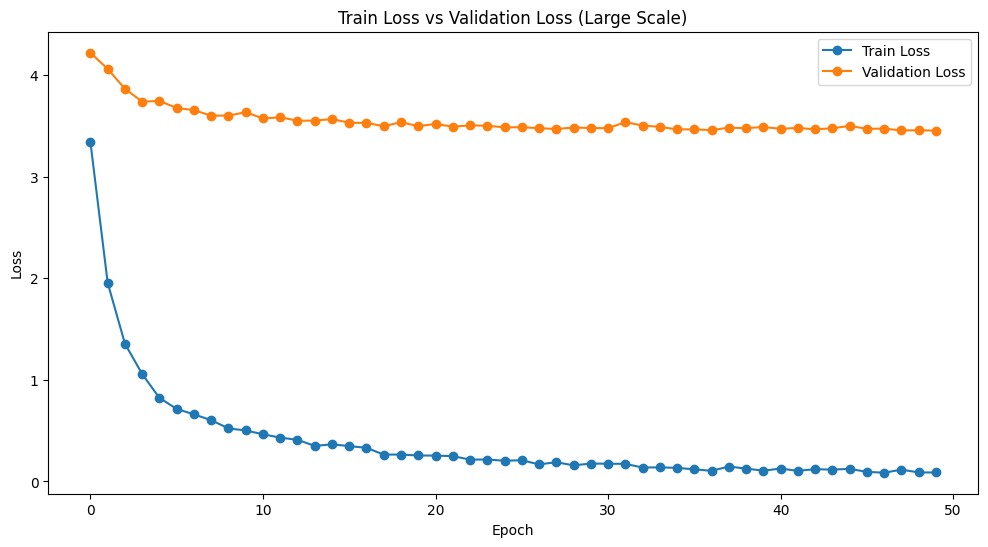

📈 Loss graph saved: /content/drive/MyDrive/YOLO/result/train_val/loss_only_graph.png


In [12]:

# ==============================================
# 2️⃣ Plot Train Loss vs Val Loss (Large Graph)
# ==============================================
def plot_loss_graph(history, save_dir):
    train_losses = [x['train_loss'] for x in history]
    val_losses = [x['val_loss'] for x in history]

    plt.figure(figsize=(12,6))
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train Loss vs Validation Loss (Large Scale)")
    plt.legend()
    save_path = os.path.join(save_dir, "loss_only_graph.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"📈 Loss graph saved: {save_path}")


plot_loss_graph(history, TRAIN_RESULT)


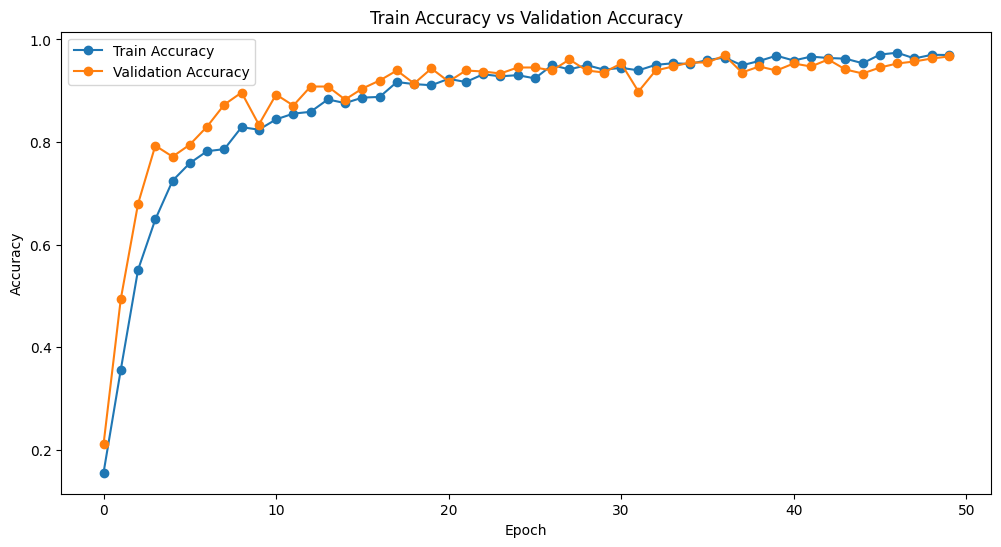

📈 Accuracy graph saved: /content/drive/MyDrive/YOLO/result/train_val/accuracy_graph.png


In [13]:
# ==============================================
# 3️⃣ Plot Train Accuracy vs Val Accuracy
# ==============================================
def plot_accuracy_graph(history, save_dir):
    train_acc = [x['train_acc'] for x in history] if "train_acc" in history[0] else None
    val_acc = [x['val_acc'] for x in history]

    plt.figure(figsize=(12,6))

    if train_acc:
        plt.plot(train_acc, label="Train Accuracy", marker="o")

    plt.plot(val_acc, label="Validation Accuracy", marker="o")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train Accuracy vs Validation Accuracy")
    plt.legend()
    save_path = os.path.join(save_dir, "accuracy_graph.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"📈 Accuracy graph saved: {save_path}")


plot_accuracy_graph(history, TRAIN_RESULT)


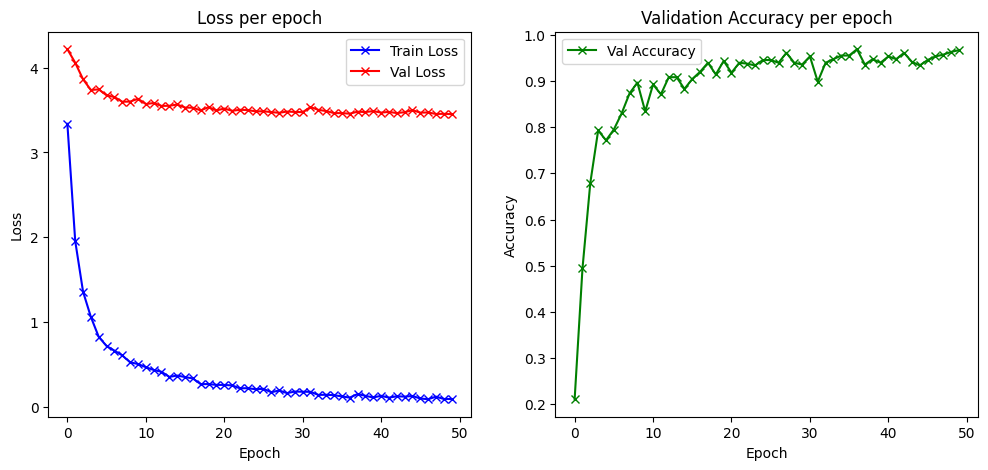

In [14]:

# ===============================================================
# 5️⃣ Plot Loss & Accuracy
# ===============================================================
def plot_history(history, save_path):
    train_losses = [x['train_loss'] for x in history]
    val_losses = [x['val_loss'] for x in history]
    val_acc = [x['val_acc'] for x in history]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, '-bx', label="Train Loss")
    plt.plot(val_losses, '-rx', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss per epoch")

    plt.subplot(1,2,2)
    plt.plot(val_acc, '-gx', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy per epoch")
    plt.legend()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_history(history, os.path.join(TRAIN_RESULT, "train_val_history_densenet201.png"))


In [16]:

# ===============================================================
# 6️⃣ Test Evaluation + Confusion Matrix + Classification Report
# ===============================================================
@torch.no_grad()
def evaluate_test(model, loader, class_names, save_path):
    model.eval()
    preds_all, labels_all = [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())

    cm = confusion_matrix(labels_all, preds_all)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="viridis")
    plt.savefig(os.path.join(save_path, "confusion_matrix_yolov12.png"), dpi=300)
    plt.show()

    report = classification_report(labels_all, preds_all, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(
        os.path.join(save_path, "classification_report_yolov12.csv")
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test (DenseNet201)")
    plt.savefig(os.path.join(save_path, "confusion_matrix_test_densenet201.png"), dpi=300)
    plt.show()
    print("\n")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(save_path, "classification_report_test_densenet201.csv"))

    # Per-class accuracy
    per_class_acc = np.diag(cm) / cm.sum(axis=1)
    plt.figure(figsize=(10,5))
    plt.bar(class_names, per_class_acc, color='skyblue')
    plt.xticks(rotation=45)
    plt.ylim(0,1)
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy - Test (DenseNet201)")
    plt.savefig(os.path.join(save_path, "per_class_accuracy_densenet201.png"), dpi=300)
    plt.show()
    print("\n")

evaluate_test(model201, test_dl, class_names, EVAL_RESULT)

# ✅ All results, best model, plots, and evaluation are saved locally


NameError: name 'model201' is not defined

In [17]:
@torch.no_grad()
def evaluate_test(model, loader, class_names, save_path):
    model.eval()
    preds_all, labels_all = [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())

    cm = confusion_matrix(labels_all, preds_all)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="viridis")
    plt.savefig(os.path.join(save_path, "confusion_matrix_yolov12.png"), dpi=300)
    plt.show()

    report = classification_report(labels_all, preds_all, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(
        os.path.join(save_path, "classification_report_yolov12.csv")
    )


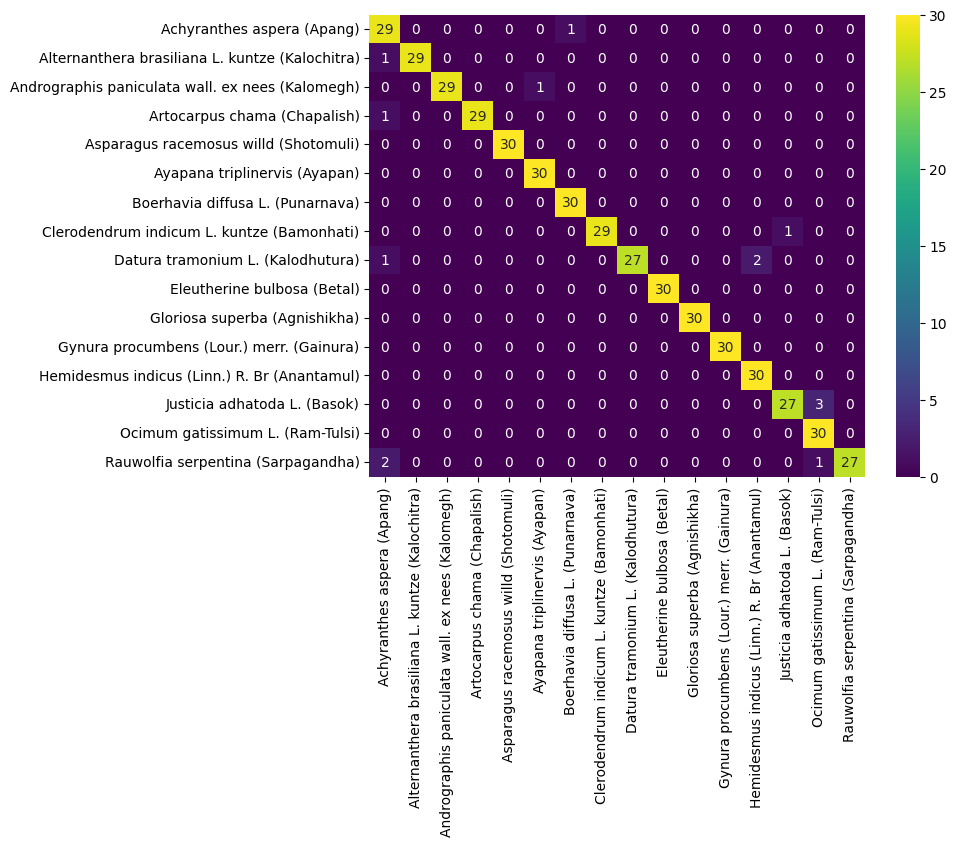

In [18]:
evaluate_test(model, test_dl, class_names, EVAL_RESULT)


In [19]:
@torch.no_grad()
def per_class_accuracy(model, loader, class_names, save_path):
    model.eval()

    num_classes = len(class_names)
    correct = np.zeros(num_classes, dtype=np.int64)
    total = np.zeros(num_classes, dtype=np.int64)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for c in range(num_classes):
            mask = (labels == c)
            correct[c] += (preds[mask] == c).sum().item()
            total[c] += mask.sum().item()

    per_class_acc = correct / np.maximum(total, 1)

    # -------------------------
    # Save CSV
    # -------------------------
    acc_df = pd.DataFrame({
        "Class": class_names,
        "Total_Samples": total,
        "Correct_Predictions": correct,
        "Accuracy": per_class_acc
    })

    acc_df.to_csv(
        os.path.join(save_path, "per_class_accuracy_yolov12.csv"),
        index=False
    )

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, per_class_acc)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy (YOLOv12)")
    plt.tight_layout()

    plt.savefig(
        os.path.join(save_path, "per_class_accuracy_yolov12.png"),
        dpi=300
    )
    plt.show()

    return acc_df


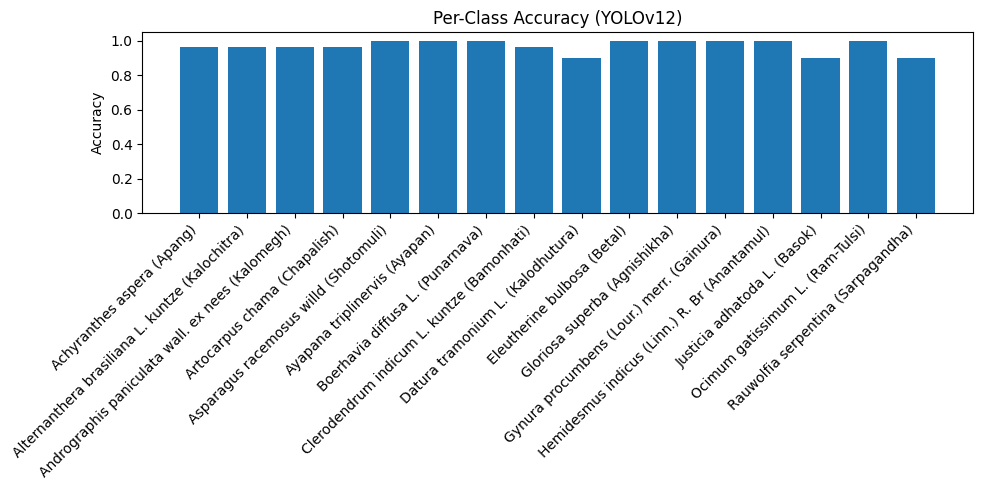

,Class,Total_Samples,Correct_Predictions,Accuracy
0,Achyranthes aspera (Apang),30,29,0.966667
1,Alternanthera brasiliana L. kuntze (Kalochitra),30,29,0.966667
2,Andrographis paniculata wall. ex nees (Kalomegh),30,29,0.966667
3,Artocarpus chama (Chapalish),30,29,0.966667
4,Asparagus racemosus willd (Shotomuli),30,30,1.000000
5,Ayapana triplinervis (Ayapan),30,30,1.000000
6,Boerhavia diffusa L. (Punarnava),30,30,1.000000
7,Clerodendrum indicum L. kuntze (Bamonhati),30,29,0.966667
8,Datura tramonium L. (Kalodhutura),30,27,0.900000
9,Eleutherine bulbosa (Betal),30,30,1.000000


In [20]:
per_class_accuracy(
    model,
    test_dl,
    class_names,
    TRAIN_RESULT
)
